In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '1'

In [3]:
from pathlib import Path
from matplotlib import pyplot as plt

In [4]:
from diffusers import StableDiffusionPipeline, UNet2DConditionModel

In [5]:
import diffusers
diffusers.__version__ 

'0.32.2'

In [6]:
from src.utils.torch_utils import add_full_name_to_module
from torch import nn
from qdiff.quant_block import QuantResBlockHF15,BaseQuantBlock,QuantBasicTransformerBlock
from diffusers.models.resnet import ResnetBlock2D
from qdiff.quant_model import QuantModel


In [7]:
if False:
    config = OmegaConf.load(f'{Path.home()}/q-diffusion/configs/stable-diffusion/v1-inference.yaml')
    model = load_model_from_config(config, "/fastdata/users/nadavg/sd/qdiff/sd-v1-4.ckpt")
    unet1_4 = model.model.diffusion_model

In [23]:
pipe = StableDiffusionPipeline.from_pretrained("SG161222/Realistic_Vision_V4.0_noVAE")
#unet = pipe.net

Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

In [24]:
#unet_org = pipe.unet
unet = pipe.unet

In [25]:
type(unet)

diffusers.models.unets.unet_2d_condition.UNet2DConditionModel

In [26]:
wq_params = {'n_bits': 8, 'channel_wise': True, 'scale_method': 'mse',
                         'symmetric':True,'debug':True}
aq_params = {'n_bits': 8, 'channel_wise': False, 'scale_method': 'mse', 
                         'leaf_param':  True, 'debug':True,'split_to_16bits':False,'act_quant_mode':'rtn'}


In [27]:
add_full_name_to_module(unet)

In [28]:
qnn = QuantModel(unet, wq_params, aq_params,quant_act_ops = True,split = True )

/home/nadavg/q-diffusion/qdiff/quant_model.py:22: FutureWarning: Accessing config attribute `in_channels` directly via 'UNet2DConditionModel' object attribute is deprecated. Please access 'in_channels' over 'UNet2DConditionModel's config object instead, e.g. 'unet.config.in_channels'.
  if hasattr(model, 'image_size'):


In [15]:
add_full_name_to_module(qnn)

In [30]:
for module in qnn.model.modules():
    if isinstance(module, QuantResBlockHF15):
        print( module.full_name,module.split)

down_blocks.0.resnets.0 0
down_blocks.0.resnets.1 0
down_blocks.1.resnets.0 0
down_blocks.1.resnets.1 0
down_blocks.2.resnets.0 0
down_blocks.2.resnets.1 0
down_blocks.3.resnets.0 0
down_blocks.3.resnets.1 0
up_blocks.0.resnets.0 1280
up_blocks.0.resnets.1 1280
up_blocks.0.resnets.2 1280
up_blocks.1.resnets.0 1280
up_blocks.1.resnets.1 1280
up_blocks.1.resnets.2 1280
up_blocks.2.resnets.0 1280
up_blocks.2.resnets.1 640
up_blocks.2.resnets.2 640
up_blocks.3.resnets.0 640
up_blocks.3.resnets.1 320
up_blocks.3.resnets.2 320
mid_block.resnets.0 0
mid_block.resnets.1 0


In [16]:
for module in qnn.model.modules():
    if isinstance(module, QuantBasicTransformerBlock):
        print( module.full_name)

model.down_blocks.0.attentions.0.transformer_blocks.0
model.down_blocks.0.attentions.1.transformer_blocks.0
model.down_blocks.1.attentions.0.transformer_blocks.0
model.down_blocks.1.attentions.1.transformer_blocks.0
model.down_blocks.2.attentions.0.transformer_blocks.0
model.down_blocks.2.attentions.1.transformer_blocks.0
model.up_blocks.1.attentions.0.transformer_blocks.0
model.up_blocks.1.attentions.1.transformer_blocks.0
model.up_blocks.1.attentions.2.transformer_blocks.0
model.up_blocks.2.attentions.0.transformer_blocks.0
model.up_blocks.2.attentions.1.transformer_blocks.0
model.up_blocks.2.attentions.2.transformer_blocks.0
model.up_blocks.3.attentions.0.transformer_blocks.0
model.up_blocks.3.attentions.1.transformer_blocks.0
model.up_blocks.3.attentions.2.transformer_blocks.0
model.mid_block.attentions.0.transformer_blocks.0


In [17]:
rsq = unet.down_blocks[0].resnets[0]
for module in rsq.modules():
    print(module, type(module))

QuantResBlockHF15(
  (act_quantizer): UniformAffineQuantizer(bit=8, scale_method=mse, symmetric=False, channel_wise=False, leaf_param=True)
  (activation_function): StraightThrough()
  (dropout): Dropout(p=0.0, inplace=False)
  (in_layers): Sequential(
    (0): QuantOp(
      (fwd_func): GroupNorm32(32, 320, eps=1e-05, affine=True)
      (act_quantizer): UniformAffineQuantizer(bit=8, scale_method=mse, symmetric=False, channel_wise=False, leaf_param=True)
      (activation_function): StraightThrough()
    )
    (1): QuantOp(
      (fwd_func): SiLU()
      (act_quantizer): UniformAffineQuantizer(bit=8, scale_method=mse, symmetric=False, channel_wise=False, leaf_param=True)
      (activation_function): StraightThrough()
    )
    (2): QuantModule(
      320, 320, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)
      (weight_quantizer): UniformAffineQuantizer(bit=8, scale_method=mse, symmetric=True, channel_wise=True, leaf_param=False)
      (act_quantizer): UniformAffineQuantizer(bit=8,

In [19]:
id(rsq.in_layers[1].act_quantizer) , id(rsq.emb_layers[0].act_quantizer),id(rsq.out_layers[1].act_quantizer)

(140600221028560, 140600214446576, 140600214447200)

In [20]:
i =0 
rsb = unet.down_blocks[i].resnets[1]
type(rsb)

qdiff.quant_block.QuantResBlockHF15

In [14]:
import torch
torch.cuda.is_available()

True

In [14]:
_=qnn.to("cuda")
_= qnn.eval()
#_=qnn.model.to("cpu")

NameError: name 'qnn' is not defined

In [15]:
pipe.unet = qnn.model

NameError: name 'qnn' is not defined

In [15]:
_=pipe.to("cuda")
#_=pipe.to("cpu")

In [16]:
pipe._execution_device

device(type='cuda', index=0)

In [17]:
generator = torch.Generator("cuda").manual_seed(42)  # 
I = pipe("a puppy wearing a hat",num_inference_steps=20,generator= generator).images[0]

  0%|          | 0/20 [00:00<?, ?it/s]

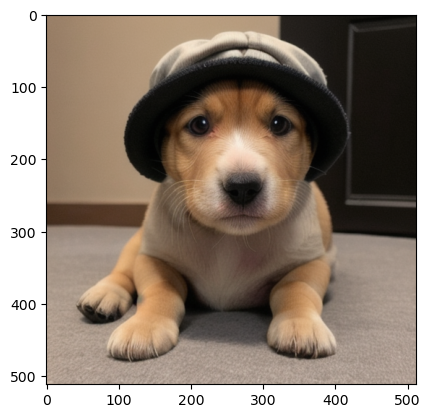

In [19]:
plt.imshow(I)

In [34]:
from src.utils.torch_utils import  save_input_hook, register_forword_hook

In [35]:
for i in range(4):
    for j in range(len(unet.down_blocks[i].resnets)):
        register_forword_hook(unet.down_blocks[i].resnets[j], save_input_hook)
    for j in range(len(unet.up_blocks[i].resnets)):
        register_forword_hook(unet.up_blocks[i].resnets[j], save_input_hook)
for j in range(2):
    register_forword_hook(unet.mid_block.resnets[j], save_input_hook)

In [32]:
pipe = StableDiffusionPipeline.from_pretrained("SG161222/Realistic_Vision_V4.0_noVAE")
unet_org = pipe.unet

Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

In [33]:
_=pipe.to("cuda")

In [49]:
generator = torch.Generator("cuda").manual_seed(42)  # Use any integer seed
I = pipe("a puppy wearing a hat",num_inference_steps=20,generator=generator).images[0]

ValueError: Cannot generate a cpu tensor from a generator of type cuda.

In [32]:
import pandas as pd
df = pd.read_parquet('eval.parquet')['Prompt']

In [35]:
df[10]

'a powerful energy woman, by alexander fedosav, hyper detailed digital matte painting, concept art, hyperrealism, 1 6 k resolution, cinema 4 d, 8 k resolution, trending on artstation, behance hd, a masterpiece, by stephan martiniere, particles, cel - shaded, power bright neon energy, by david a. hardy,'

In [36]:
prompt = """ young, curly haired, redhead Natalie Portman as a optimistic!, 
    cheerful, giddy medieval innkeeper in a dark medieval inn. dark shadows, 
    colorful, candle light, law contrasts, fantasy concept art by Jakub Rozalski, Jan Matejko, and J.Dickenson"""

prompt = df[10] #"a girl playing with a barbie doll"
generator = torch.Generator("cuda").manual_seed(42)  # Use any integer seed
I = pipe(prompt,num_inference_steps=20,generator=generator).images[0]

  0%|          | 0/20 [00:00<?, ?it/s]

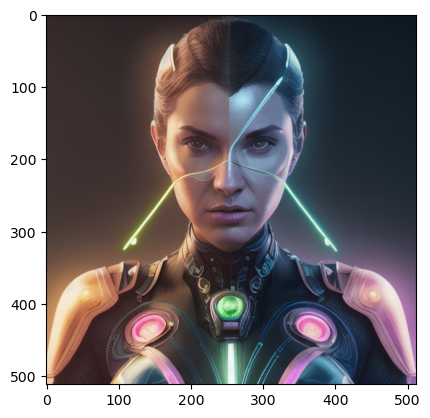

In [37]:
plt.imshow(I)

In [27]:
import torch

In [28]:
i,j = 0,0
#rbq1  = unet.up_blocks[i].resnets[j].cpu()
#rb1 = unet_org.up_blocks[i].resnets[j].cpu()

rbq1  = qnn.model.down_blocks[i].resnets[j].cpu()
rb1 = unet_org.down_blocks[i].resnets[j].cpu()
#rbq1  = qnn.model.up_blocks.resnets[j].cpu()
#rb1 = unet_org.up_blocks.resnets[j].cpu()
#rbq1  = qnn.model.mid_block.resnets[j].cpu()
#rb1 = unet_org.mid_block.resnets[j].cpu()
type(rbq1),type(rb1)

NameError: name 'unet_org' is not defined

In [52]:
in1 = rbq1.saved_inputs[0]
in1 = [x.detach().cpu() for x in in1]
[ii.shape for ii in in1]

[torch.Size([2, 320, 64, 64]), torch.Size([2, 1280])]

In [75]:
torch.sum(torch.abs(rbq1(*in1) - rb1(*in1)))

tensor(5085658.5000, grad_fn=<SumBackward0>)

In [61]:

[(rbq1.in_layers[i].use_act_quant,rbq1.in_layers[i].use_weight_quant) for i in range(3)]

[(False, False), (False, False), (False, False)]

In [73]:
type(rb1),type(rbq1),rbq1.in_layers[2].fwd_func

(diffusers.models.resnet.ResnetBlock2D,
 qdiff.quant_block.QuantResBlockHF15,
 <function torch._VariableFunctionsClass.conv2d>)

In [74]:
rb1.conv1.bias - rbq1.in_layers[2].org_bias

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 

In [71]:
rb1.conv1.weight - rbq1.in_layers[2].org_weight

tensor([[[[0., 0., 0.],
          [0., 0., 0.],
          [0., 0., 0.]],

         [[0., 0., 0.],
          [0., 0., 0.],
          [0., 0., 0.]],

         [[0., 0., 0.],
          [0., 0., 0.],
          [0., 0., 0.]],

         ...,

         [[0., 0., 0.],
          [0., 0., 0.],
          [0., 0., 0.]],

         [[0., 0., 0.],
          [0., 0., 0.],
          [0., 0., 0.]],

         [[0., 0., 0.],
          [0., 0., 0.],
          [0., 0., 0.]]],


        [[[0., 0., 0.],
          [0., 0., 0.],
          [0., 0., 0.]],

         [[0., 0., 0.],
          [0., 0., 0.],
          [0., 0., 0.]],

         [[0., 0., 0.],
          [0., 0., 0.],
          [0., 0., 0.]],

         ...,

         [[0., 0., 0.],
          [0., 0., 0.],
          [0., 0., 0.]],

         [[0., 0., 0.],
          [0., 0., 0.],
          [0., 0., 0.]],

         [[0., 0., 0.],
          [0., 0., 0.],
          [0., 0., 0.]]],


        [[[0., 0., 0.],
          [0., 0., 0.],
          [0., 0., 0.]],

    

In [79]:
rbq1.in_layers[0].use_act_quant,rbq1.in_layers[0].use_weight_quant

(False, False)

In [93]:
p1 = list(rb1.norm1.named_parameters())
p2 = list(rbq1.in_layers[0].named_parameters())

In [96]:
p1[0][1]-p2[0][1]

tensor([-0.5349, -0.4956, -0.6538, -0.5229, -0.5791, -0.5122, -0.4951, -0.6182,
        -0.5657, -0.5596, -0.5376, -0.5627, -0.6453, -0.6497, -0.5620, -0.4790,
        -0.3975, -0.5557, -0.5803, -0.6453, -0.2598, -0.5901, -0.3184, -0.6279,
        -0.5828, -0.5266, -0.5447, -0.3564, -0.4639, -0.5583, -0.5505, -0.5688,
        -0.5669, -0.4697, -0.4966, -0.5896, -0.4673, -0.5579, -0.5364, -0.5554,
        -0.4795, -0.6326, -0.5398, -0.4771, -0.6497, -0.5132, -0.4653, -0.7190,
        -0.4937, -0.4863, -0.4517, -0.5698, -0.7754, -0.6907, -0.6379, -0.5364,
        -0.6514, -0.5867, -0.4595, -0.4819, -0.6284, -0.4116, -0.4233, -0.4111,
        -0.5486, -0.4785, -0.6418, -0.5344, -0.4653, -0.6606, -0.5969, -0.5952,
        -0.5559, -0.6609, -0.4819, -0.6594, -0.6438, -0.6240, -0.5510, -0.6750,
        -0.5657, -0.5991, -0.5857, -0.6243, -0.3789, -0.6208, -0.6084, -0.6743,
        -0.5071, -0.4937, -0.6023, -0.5708, -0.6208, -0.5803, -0.3423, -0.7523,
        -0.5339, -0.6089, -0.6765, -0.54

In [85]:
rb1.norm1, rbq1.in_layers[0].fwd_func

(GroupNorm(32, 320, eps=1e-05, affine=True),
 GroupNorm32(32, 320, eps=1e-05, affine=True))

In [77]:
rb1.norm1(in1[0])- rbq1.in_layers[0](in1[0])

tensor([[[[ 0.2857,  0.8974, -0.5730,  ...,  0.8141,  0.4031, -0.4887],
          [-0.1720,  0.0520,  0.2181,  ..., -0.7669,  1.3792,  0.2344],
          [ 0.2377, -0.1785,  0.1209,  ..., -1.3885,  0.2096,  1.3065],
          ...,
          [ 0.0762, -0.6034,  1.0254,  ...,  0.2082, -0.7856,  0.2671],
          [ 0.5985, -0.2370,  0.9233,  ..., -0.1041, -0.7683,  0.8059],
          [-0.1409, -0.6457,  0.4895,  ...,  0.5052,  0.1066,  0.1508]],

         [[-0.3491,  0.2868,  0.2274,  ..., -0.2222, -0.0061,  0.1422],
          [ 0.5032, -0.0187, -0.1605,  ...,  0.4746,  0.1507, -0.5485],
          [ 0.5451, -0.2080, -0.3144,  ...,  0.6297, -0.1205, -0.3248],
          ...,
          [ 1.2693, -0.1174,  0.3715,  ..., -0.0256,  0.5815,  0.0305],
          [-0.0504, -0.4795,  0.3374,  ..., -0.0138, -0.3134,  0.0417],
          [ 0.7875,  0.1350, -0.2476,  ...,  0.0471,  0.0527, -0.0439]],

         [[-0.2209, -0.8277, -0.5248,  ...,  0.0590, -0.6424, -0.4763],
          [ 0.7326, -0.4322, -